<a href="https://colab.research.google.com/github/rkdevesh003-hub/eos-ai-workshop/blob/main/partA_fashion_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part A – Fashion Item Classifier🧥🩳👗👟

## CELL 1 – Imported libraries

In [ ]:
import tensorflow as tf
from tensorflow . keras import layers , models
import matplotlib . pyplot as plt
import numpy as np
print ('tf version :', tf . __version__ )


tf version : 2.20.0


## CELL 2 – Loaded MNIST

### Task A1 – Swaped the dataset to Fashion_MNIST also added the snippet of class names.


Re-ran cells 2–7.

Recordings:


---



• Train accuracy after epoch 5= 88.45%


• Test accuracy= 87.80%


• Did the gap between train and test grow vs MNIST?


answer: Yes, the gap between test and train accuracy has grown by 0.5%.


In [ ]:
# Load the dataset that comes built into Keras
( x_train , y_train ) , ( x_test , y_test ) = tf . keras . datasets .fashion_mnist. load_data ()

# Normalise pixel values from 0..255 to 0..1 ( helps training )
x_train = x_train . astype ('float32') / 255.0
x_test = x_test . astype ('float32') / 255.0

print ('train shape :', x_train . shape ) # (60000 , 28 , 28)
print ('test shape :', x_test . shape ) # (10000 , 28 , 28)


train shape : (60000, 28, 28)
test shape : (10000, 28, 28)


## CELL 3 – peek at 16 random images

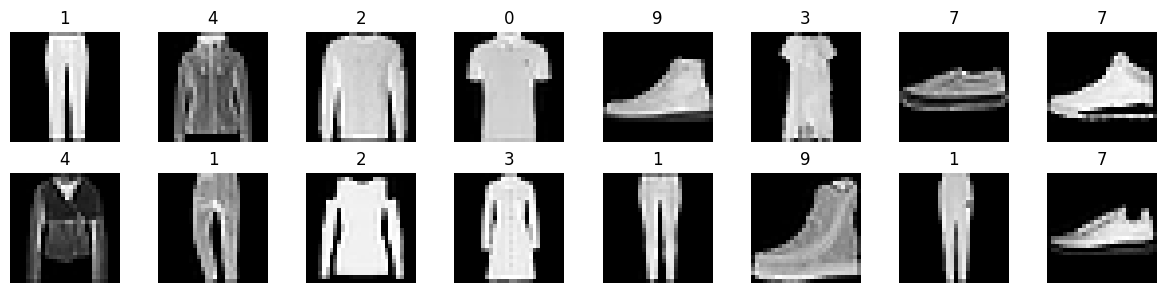

In [ ]:
fig , axes = plt . subplots (2 , 8 , figsize =(12 , 3) )
for ax in axes . flat :
  i = np . random . randint ( len( x_train ) )
  ax . imshow ( x_train [ i ] , cmap ='gray')
  ax. set_title ( class_names [ y_train [i ]])
  ax . set_title ( int( y_train [ i ]) )
  ax . axis ('off')
plt . tight_layout () ; plt . show ()

In [ ]:
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
# Then in your imshow loop , use: ax. set_title ( class_names [ y_train [i ]])


## CELL 4 – Building the CNN

### Task A2 – Added a third Convulation layer

re-ran from 4th cell.

Recordings:


---
- Test accuracy= 87.42%

- Train accuracy= 88.06%

The Test accuracy went down by 0.38%





### STRETCH TASK:

Added data augmentation in cell 4.


---


Recordings:

- Test accuracy= 80.81%

- Train accuracy= 80.95%


---
Did the gap between train and test accuracy shrink?

answer:Yes the gap shrank by 0.5%.



In [ ]:
model = models . Sequential ([

# Reshape adds a " channel " dimension : (28 , 28) -> (28 , 28 , 1)
layers . Reshape ((28 , 28 , 1) , input_shape =(28 , 28) ) ,

layers . RandomFlip ('horizontal') ,
layers . RandomRotation (0.1) ,


# Conv layer 1: 8 filters of size 3x3 + ReLU activation
layers . Conv2D (8 , 3 , activation ='relu', padding ='same') ,
layers . MaxPooling2D (2) , # halve spatial size

# Conv layer 2: 16 filters
layers . Conv2D (16 , 3 , activation ='relu', padding ='same') ,
layers . MaxPooling2D (2) ,

layers . Conv2D (32 , 3 , activation ='relu', padding ='same') ,
layers . MaxPooling2D (2) ,


# Flatten 7 x7x16 = 784 numbers -> a single long vector
layers . Flatten () ,
layers . Dense (32 , activation = 'relu') ,

# 10 output classes -> softmax gives 10 probabilities that sum to 1
layers . Dense (10 , activation ='softmax') ,
])

model . compile (
optimizer ='adam',
loss ='sparse_categorical_crossentropy',
metrics =['accuracy'])

model . summary ()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_6 (Reshape)             │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_3 (RandomFlip)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_3               │ (None, 28, 28, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 28, 28, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 7, 7, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,466 (60.41 KB)

 Trainable params: 15,466 (60.41 KB)

 Non-trainable params: 0 (0.00 B)

## CELL 5 – Training for epochs

### Task A3 – Training longer and watching for overfitting

Recordings:


---
• Around which epoch does validation accuracy stop improving?

answer: The validation accuracy stopped improving after the 5th epoch.Though
       the test accuracy went up & down at last it was lower compared to train accuracy which was a live overfitting.


---



• Does train accuracy keep going up after that? What’s that called?


answer: The train accuracy kept improving in the epochs.This condition is termed as 'generalisation gap'.     
       


In [ ]:
history = model . fit (
x_train , y_train ,
epochs =15 ,
validation_split =0.1 ,
batch_size =128 ,
verbose =2)


Epoch 1/15
422/422 - 15s - 35ms/step - accuracy: 0.8193 - loss: 0.5016 - val_accuracy: 0.8123 - val_loss: 0.5097
Epoch 2/15
422/422 - 15s - 35ms/step - accuracy: 0.8250 - loss: 0.4813 - val_accuracy: 0.8135 - val_loss: 0.5057
Epoch 3/15
422/422 - 15s - 36ms/step - accuracy: 0.8302 - loss: 0.4706 - val_accuracy: 0.8238 - val_loss: 0.4817
Epoch 4/15
422/422 - 15s - 35ms/step - accuracy: 0.8351 - loss: 0.4563 - val_accuracy: 0.8257 - val_loss: 0.4669
Epoch 5/15
422/422 - 15s - 36ms/step - accuracy: 0.8389 - loss: 0.4436 - val_accuracy: 0.8213 - val_loss: 0.4857
Epoch 6/15
422/422 - 20s - 48ms/step - accuracy: 0.8426 - loss: 0.4351 - val_accuracy: 0.8385 - val_loss: 0.4340
Epoch 7/15
422/422 - 21s - 49ms/step - accuracy: 0.8447 - loss: 0.4287 - val_accuracy: 0.8387 - val_loss: 0.4244
Epoch 8/15
422/422 - 15s - 36ms/step - accuracy: 0.8464 - loss: 0.4243 - val_accuracy: 0.8360 - val_loss: 0.4314
Epoch 9/15
422/422 - 16s - 37ms/step - accuracy: 0.8499 - loss: 0.4113 - val_accuracy: 0.8348 - 

## CELL 6 – Plotted accuracy curves

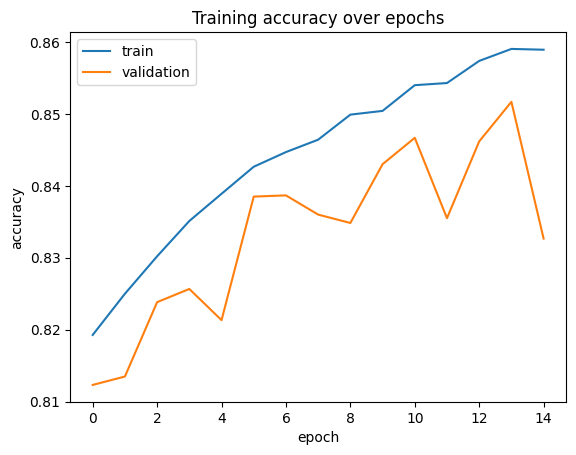

In [ ]:
plt . plot ( history . history ['accuracy'] , label ='train')
plt . plot ( history . history ['val_accuracy'] , label ='validation')
plt . xlabel ('epoch') ; plt . ylabel ('accuracy') ; plt . legend ()
plt . title ('Training accuracy over epochs')
plt . show ()

## CELL 7 – Evaluation on the test set

In [ ]:
test_loss , test_acc = model . evaluate ( x_test , y_test , verbose =0)
train_acc = history . history ['accuracy'][-1]
print ( f'Test accuracy on MNIST : { test_acc :.2%}')
print ( f'Training accuracy on MNIST : { train_acc :.2%}')


Test accuracy on MNIST : 83.21%
Training accuracy on MNIST : 85.89%


## CELL 8 – confusion matrix

### Task A4 – Confusion matrix

- Identified three most confused classes:


---
Recordings:

| true_Class | predicted_Class | count |
| :--- | :--- | :---: |
| sneaker|  sandal | 174 |
| coat |   pullover|172|
| T-shirt |shirt | 147|


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


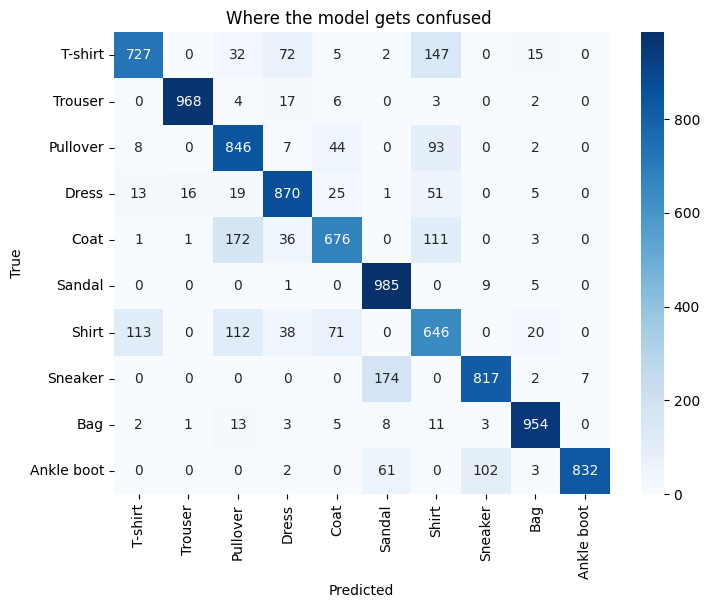

In [ ]:
from sklearn . metrics import confusion_matrix
import seaborn as sns

preds = model . predict ( x_test ) . argmax ( axis =1)

cm = confusion_matrix ( y_test , preds )

plt . figure ( figsize =(8 , 6) )
sns . heatmap ( cm , annot = True , fmt ='d', cmap ='Blues',
                xticklabels = class_names , yticklabels = class_names )
plt . xlabel ('Predicted') ; plt . ylabel ('True')
plt . title ('Where the model gets confused ') ; plt . show ()


## CELL 9 – Display 9 misclassified images

### Task A5 – Finding 3 specific misclassifications


---
Recordings(thinking may vary from person to person):
---


- T-shirt vs dress:




    "People often confuse T-shirts and dresses due to the difference between casual and formal clothes , particularly with the popularity of the 'T-shirt dress', which combines the comfort of a T-shirt with the length of a dress."|


---
- Ankleboot vs Sneaker:


    "Most people confuse ankleboot as sneakers because of
    modern shoes (like some high-top sneakers or fashion boots)
    has elements of sneaker like rubber soles but covering the ankle like an ankleboot."
         
         
          
---
- Shirt vs Coat  :

    "People mostly make mistakes by thinking shirt as coat because both     items has similar structures, such as button-up fronts, collars, and cuffs."






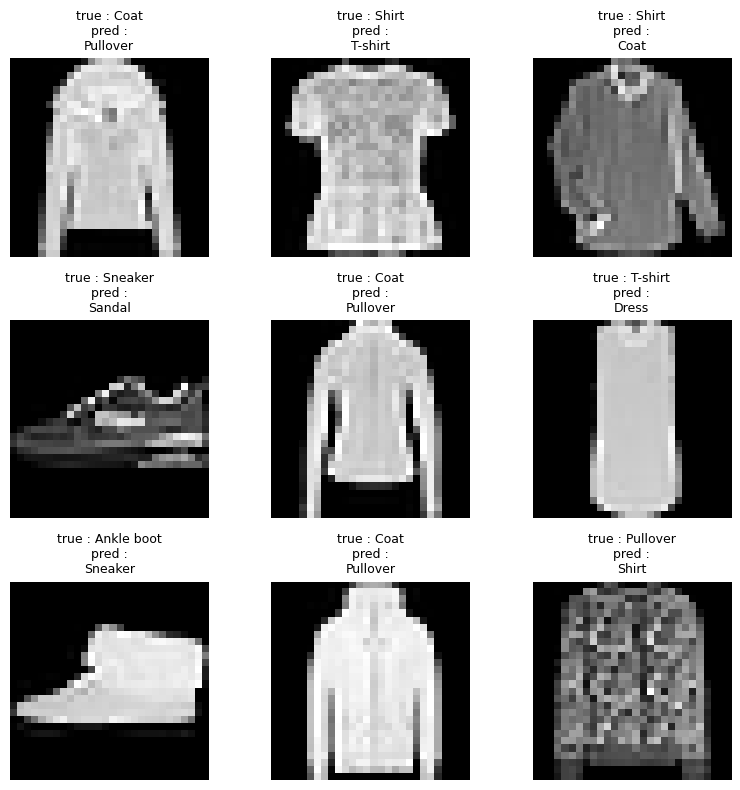

In [ ]:
wrong = np . where ( preds != y_test ) [0]
sample = np . random . choice ( wrong , 9 , replace = False )

fig , axes = plt . subplots (3 , 3 , figsize =(8 , 8) )
for ax , i in zip( axes . flat , sample ) :
    ax . imshow ( x_test [ i ] , cmap ='gray')
    ax . set_title (f'true : { class_names [ y_test [i ]]}\npred :\n{ class_names [ preds [i]]}', fontsize =9)
    ax . axis ('off')
plt . tight_layout () ; plt . show ()